# Bài 4: Chạy thử nghiệm và đọc kết quả ablation

Bài này chạy từ ảnh gốc đến bảng so sánh: RGB, biểu diễn Wavelet Haar và RGB có trọng số cho nhóm Fake ít biên. Sau đó ta thử chọn ngưỡng riêng cho ảnh xám/màu.

**Trên Colab:** chọn **Runtime → Change runtime type → T4 GPU**, rồi bấm **Run all**. Mặc định mỗi nhánh học 15 epoch trên fold 0. Thời gian phụ thuộc GPU và tốc độ tải dữ liệu; cell huấn luyện in tiến độ sau mỗi epoch.

Ba nhánh dùng cùng ResNet18 và cùng cách chia dữ liệu để so tác động của biểu diễn Haar và trọng số mẫu. Phần `reference` đọc các dự đoán đã lưu trong bài đọc; cấu hình của chúng được ghi ở từng bảng.

In [1]:
from pathlib import Path
import importlib
import os
import subprocess
import sys

URL = "https://github.com/Purin1410/Olympic_AI_PTIT_2026_preliminary_round.git"
REF = os.environ.get("AILAAI_RELEASE_REF", "main")
# Reuse a local checkout when the notebook is opened from this repository.
TASK = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/ailaai").is_dir() and (p / "pyproject.toml").is_file()), None)
if TASK is None:
    REPO = Path("/content" if Path("/content").is_dir() else Path.cwd()) / "Olympic_AI_PTIT_2026_preliminary_round"
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", REF, URL, str(REPO)], check=True)
    TASK = REPO / "AI_LA_AI"
else:
    REPO = TASK.parent
if not (TASK / "src/ailaai").is_dir():
    raise FileNotFoundError(f"Không tìm thấy package AI Là AI trong {TASK}.")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(TASK / "requirements-colab.txt"), "-e", str(TASK)], check=True)
src_path = str((TASK / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)
importlib.invalidate_caches()
import ailaai
if Path(ailaai.__file__).resolve().parent != TASK.resolve() / "src/ailaai":
    raise RuntimeError("Phiên đang dùng bản ailaai ở thư mục khác. Khởi động lại phiên rồi chạy từ đầu.")
print("Đã sẵn sàng:", TASK)

Đã sẵn sàng: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI


In [2]:
from pathlib import Path
from typing import Any, Callable, Mapping, Iterable
from dataclasses import dataclass, replace
import hashlib, json, time, os, tempfile, zipfile
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.prop_cycle": plt.cycler(color=["#2563A6", "#C17817", "#7A5BA7"])})
from IPython.display import display
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import functional as TF, InterpolationMode
from ailaai.config import TrainConfig, Workspace, write_json
from ailaai.data import decode_rgb
from ailaai.models import attach_optimizer_groups
from ailaai.metrics import classification_report
from ailaai.predictions import PredictionTable
from ailaai.resources import sha256_file
# Các hàm dưới quản lý checkpoint/config; phép học được viết ở các cell tiếp theo.
from ailaai.engine import (RunInfo, _resolved_config, _run_directory, _load_checkpoint,
                          _seed, _save_curves, _checkpoint_state, _callable_digest)
ModelFactory = Callable[..., nn.Module]
ViewFunction = Callable[[torch.Tensor], torch.Tensor]

## 1. Chọn cách chạy

Giữ `MODE = "train"` để tải ảnh và huấn luyện thật. Đổi thành `"reference"` nếu chỉ muốn đọc các dự đoán lịch sử trên CPU.

`FOLDS = [0]` chạy một fold với 1.600 ảnh train và 400 ảnh validation. Muốn tạo dự đoán OOF cho đủ 2.000 ảnh, đổi thành `[0, 1, 2, 3, 4]`. Khi đó notebook huấn luyện 15 mô hình: ba nhánh cho mỗi fold.

Ở chế độ `reference`, `REFERENCE_FOLDS` mặc định gồm cả năm fold để đối chiếu đủ 2.000 ảnh trong Reading. Có thể chọn ít fold hơn để xem riêng, nhưng cần giữ đúng số ảnh khi diễn giải.

Checkpoint được lưu sau từng epoch. Chạy lại trong cùng runtime sẽ tiếp tục phần còn thiếu hoặc dùng lại lượt đã hoàn tất. Nếu xóa runtime Colab, cần lưu thư mục `artifacts/` ra ngoài trước.

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.prop_cycle": plt.cycler(color=["#2563A6", "#C17817", "#7A5BA7"])})
import torch
from IPython.display import display
from ailaai.config import Workspace, load_config, config_with
from ailaai.data import load_train_manifest, load_fold_split, decode_rgb
from ailaai.resources import prepare_resources
from ailaai.transforms import native_view
from ailaai.ablation import (haar_view, image_features, low_edge_weights,
                            paired_report, calibration_split, choose_group_thresholds)
from ailaai.metrics import classification_report, macro_f1

MODE = "train"
FOLDS = [0]
REFERENCE_FOLDS = [0, 1, 2, 3, 4]  # phạm vi đọc kết quả đã lưu
EPOCHS = 15
RUN_ID = "lesson_nb4_reading_v2"
if MODE not in {"train", "reference"}:
    raise ValueError('MODE chỉ nhận "train" hoặc "reference".')
if not FOLDS or len(set(FOLDS)) != len(FOLDS) or not set(FOLDS) <= set(range(5)):
    raise ValueError("FOLDS cần các fold khác nhau trong 0..4.")
if not REFERENCE_FOLDS or len(set(REFERENCE_FOLDS)) != len(REFERENCE_FOLDS) or not set(REFERENCE_FOLDS) <= set(range(5)):
    raise ValueError("REFERENCE_FOLDS cần các fold khác nhau trong 0..4.")
if MODE == "train" and not torch.cuda.is_available():
    raise RuntimeError('Chọn T4 GPU rồi chạy lại, hoặc đổi MODE thành "reference" để đọc kết quả trên CPU.')
ws = Workspace.from_root(TASK, run_id=RUN_ID)
cfg = config_with(load_config(TASK / "configs/rgb_native358.json"), epochs=EPOCHS,
                  model={"backbone": "resnet18", "weights": "IMAGENET1K_V1"})
MODEL_SPEC = dict(cfg.model)
print("Chế độ:", MODE, "| folds:", FOLDS, "| epoch mỗi nhánh:", EPOCHS)
print("Kết quả:", ws.output_root)

Chế độ: train | folds: [0] | epoch mỗi nhánh: 15
Kết quả: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/lesson_nb4_reading_v2


## 2. Tải dữ liệu và kiểm tra cách chia

Bộ ảnh có tại [who_is_AI (Google Drive)](https://drive.google.com/file/d/1g_43_Xn-DWYB-k7Yq4XQTr5ZQXZ0UdXq/view?usp=drive_link). Cell dưới tự tải, giải nén và tìm thư mục ảnh. Bảng chia fold cố định giúp các nhánh được so sánh trên cùng ảnh.

Ở chế độ `reference`, notebook dùng CSV đã đóng gói trong repo và không tải ảnh gốc.

In [4]:
if MODE == "train":
    prepare_resources(ws, TASK / "configs/resources.json", profile="train")
    train = load_train_manifest(ws)
    print("Ảnh train:", len(train))
    display(train.label.value_counts().sort_index().rename(index={0: "Real", 1: "Fake"}))
    for fold in FOLDS:
        fit_rows, val_rows = load_fold_split(train, TASK / "assets/splits/train_folds.csv", fold)
        print(f"Fold {fold}: train {len(fit_rows)}, validation {len(val_rows)}")
else:
    reference_dir = TASK / "data/negative_results"
    results = pd.read_csv(reference_dir / "oof_predictions.csv")
    results = results[results.fold.isin(REFERENCE_FOLDS)].copy()
    cutoffs = {int(item["fold"]): float(item["cutoff"])
               for item in json.loads((reference_dir / "promotion_gates.json").read_text())["cutoffs"]}
    print("Đang đọc dự đoán lịch sử:", len(results), "ảnh")

Đang tải bộ dữ liệu từ Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1g_43_Xn-DWYB-k7Yq4XQTr5ZQXZ0UdXq
From (redirected): https://drive.google.com/uc?id=1g_43_Xn-DWYB-k7Yq4XQTr5ZQXZ0UdXq&confirm=t&uuid=b2d2bcc6-ba55-4aad-b0e8-f07439745d62
To: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/data/who_is_AI.zip.partial
100%|██████████| 146M/146M [00:01<00:00, 103MB/s] 


Đang giải nén và kiểm tra dữ liệu...
Dữ liệu đã sẵn sàng: train 2000 ảnh
Ảnh train: 2000


,count
label,
Real,1000
Fake,1000


Fold 0: train 1600, validation 400


### Viết phép phân rã Haar

Hàm dưới tính LL, LH, HL, HH rồi xếp bốn dải vào bốn góc của mỗi kênh màu. Bài thực hành dùng cách biểu diễn này khi huấn luyện; thử nghiệm Wavelet R18 lịch sử có cấu hình khác.

In [5]:
# Định nghĩa trực tiếp trong cell: haar_view
def haar_view(images: torch.Tensor, crop: int = 358) -> torch.Tensor:
    """Tile four Haar bands into each RGB channel, keeping a three-channel view.

    LL is divided by two; signed details are scaled and centered at 0.5.
    Each quadrant is 179x179 for a 358 crop; no per-image normalization is used.
    """
    if crop < 2 or crop % 2:
        raise ValueError("Haar crop must be a positive even integer.")
    x = native_view(images, crop)
    a, b = x[..., 0::2, 0::2], x[..., 0::2, 1::2]
    c, d = x[..., 1::2, 0::2], x[..., 1::2, 1::2]
    ll = (a + b + c + d) / 4
    lh = (a - b + c - d) / 4 + 0.5
    hl = (a + b - c - d) / 4 + 0.5
    hh = (a - b - c + d) / 4 + 0.5
    return torch.cat((torch.cat((ll, lh), dim=-1), torch.cat((hl, hh), dim=-1)), dim=-2)

### Tạo ResNet và thay tầng phân loại

Khi bắt đầu học, mô hình nạp trọng số ImageNet rồi thay classifier bằng tầng hai đầu ra. Khi đọc checkpoint, ta chỉ cần dựng lại kiến trúc; trọng số sẽ lấy từ checkpoint đó.

In [6]:
from torchvision import models as tv_models
_BUILDERS = {"resnet34": (tv_models.resnet34, tv_models.ResNet34_Weights),
             "resnet18": (tv_models.resnet18, tv_models.ResNet18_Weights)}

In [7]:
# Định nghĩa trực tiếp trong cell: model_factory
def model_factory(
    backbone: str = "resnet34",
    weights: str | None = "IMAGENET1K_V1",
    initialize: bool = True,
) -> nn.Module:
    """Build a two-class model, optionally starting from ImageNet weights."""
    if backbone not in _BUILDERS:
        raise ValueError(f"Unsupported backbone {backbone!r}; choose one of {sorted(_BUILDERS)}.")
    builder, enum = _BUILDERS[backbone]
    selected = enum[weights] if initialize and weights else None
    model = builder(weights=selected)
    if not hasattr(model, "fc") or not isinstance(model.fc, nn.Linear):
        raise ValueError(f"The {backbone} builder does not expose the expected linear fc head.")
    model.fc = nn.Linear(model.fc.in_features, 2)
    return attach_optimizer_groups(model, model.fc)

In [8]:
build_model = model_factory

## 3. RGB và Wavelet nhìn ảnh như thế nào?

Ta cắt vùng giữa ảnh thành 358 × 358, tương ứng khoảng 70% chiều dài mỗi cạnh của ảnh 512 × 512.

Nhánh RGB giữ vùng cắt này. Nhánh Haar phân rã thành bốn dải LL, LH, HL, HH rồi xếp chúng vào bốn góc của từng kênh màu. Các dải chi tiết có thể âm nên được đưa về quanh 0,5; đầu ra vẫn có ba kênh và kích thước 358 × 358.

Cả hai nhánh dùng ResNet18, trọng số ImageNet, cùng seed và lịch học. Như vậy ta không đổi backbone khi thử biểu diễn ảnh. Cách xếp bốn dải ở đây được viết rõ trong `haar_view`; đây là lựa chọn cho bài thực hành, chưa phải công thức tốt nhất.

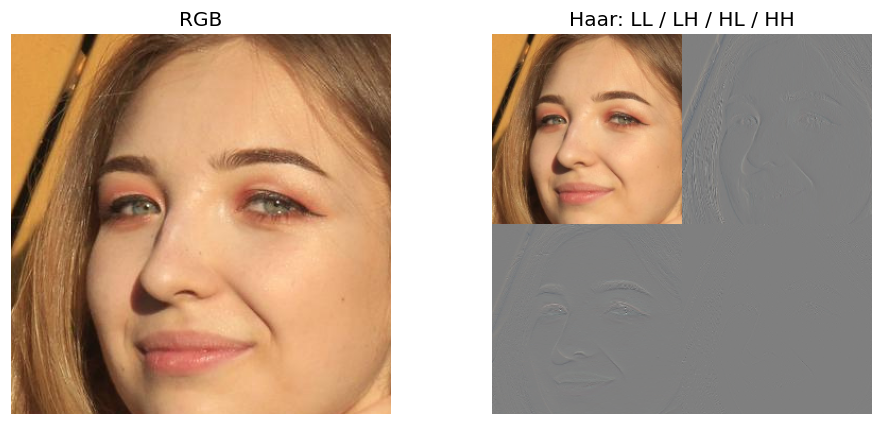

In [9]:
def student_model_factory(*, initialize):
    return build_model(MODEL_SPEC["backbone"], MODEL_SPEC["weights"], initialize=initialize)

def rgb_view(batch):
    return native_view(batch, crop=358)

def wavelet_view(batch):
    return haar_view(batch, crop=358)

RGB_SPEC = {"name": "native", "crop": 358}
WAVELET_SPEC = {"name": "haar_quadrants", "crop": 358, "version": 1}
if MODE == "train":
    sample = decode_rgb(train.iloc[0].path)
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, title, view in zip(axes, ["RGB", "Haar: LL / LH / HL / HH"],
                               [rgb_view(sample), wavelet_view(sample)]):
        ax.imshow(view.permute(1, 2, 0).numpy())
        ax.set_title(title)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(ws.output_root / "input_views.png", dpi=150)
    plt.show()

### Tính tỷ lệ biên và trọng số mẫu

Lượt huấn luyện trong notebook tính tỷ lệ biên bằng Sobel. Ngưỡng phân nhóm lấy từ các ảnh Fake thuộc train fold. Khi đọc bundle lịch sử, ta dùng đặc trưng Laplacian đã lưu cùng thông tin nguồn của bundle.

In [10]:
# Định nghĩa trực tiếp trong cell: image_features,low_edge_weights
def image_features(rows: pd.DataFrame, crop: int = 358, edge_threshold: float = 0.08) -> pd.DataFrame:
    """Compute gray flag and Sobel edge fraction directly from the current images."""
    records = []
    sobel = torch.tensor([[[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]],
                          [[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]])[:, None] / 8
    for i, row in enumerate(rows.itertuples(), 1):
        rgb = native_view(decode_rgb(row.path), crop)
        is_gray = bool((rgb.max(0).values - rgb.min(0).values).mean() <= 1 / 255)
        gray = (rgb * rgb.new_tensor([0.299, 0.587, 0.114])[:, None, None]).sum(0)[None, None]
        gradients = F.conv2d(F.pad(gray, (1, 1, 1, 1), mode="reflect"), sobel)
        fraction = float((gradients.square().sum(1).sqrt() > edge_threshold).float().mean())
        records.append({"file_name": row.file_name, "is_gray": int(is_gray), "edge_ratio": fraction})
        if i % 200 == 0 or i == len(rows):
            print(f"Đã tính đặc trưng ảnh {i}/{len(rows)}", flush=True)
    return pd.DataFrame(records)


def low_edge_weights(fit_rows: pd.DataFrame, multiplier: float = 1.5) -> tuple[dict[str, float], float]:
    """Choose the bottom fake quartile using training rows only, preserving class mass.

    Strict inequality at the cutoff keeps tied/constant features from overweighting
    the entire class. No low-edge group means all weights stay one.
    """
    if not np.isfinite(multiplier) or multiplier < 1:
        raise ValueError("Weight multiplier must be finite and at least one.")
    fake = fit_rows[fit_rows.label == 1]
    if fake.empty or not np.isfinite(fit_rows.edge_ratio).all():
        raise ValueError("Training data needs finite edge ratios and Fake examples.")
    cutoff = float(fake.edge_ratio.quantile(0.25))
    low = (fit_rows.label == 1) & (fit_rows.edge_ratio < cutoff)
    n_low, n_fake = int(low.sum()), len(fake)
    other = (n_fake - multiplier * n_low) / (n_fake - n_low)
    if other <= 0:
        raise ValueError("Multiplier would make the remaining Fake weights nonpositive.")
    values = np.ones(len(fit_rows))
    values[fit_rows.label.to_numpy() == 1] = other
    values[low.to_numpy()] = multiplier
    return dict(zip(fit_rows.file_name, values)), cutoff

## 4. Chọn nhóm Fake ít biên từ tập train

Ở bài thực hành này, `edge_ratio` là tỷ lệ pixel có độ lớn gradient Sobel vượt 0,08 trên vùng cắt. Ảnh xám được nhận diện qua mức chênh lệch giữa ba kênh màu. Ta tính cả hai từ ảnh đang dùng, không ghép đặc trưng lịch sử vào lượt chạy mới.

Mỗi fold chọn ngưỡng phân vị 25% từ **ảnh Fake của phần train**. Ảnh Fake thấp hơn ngưỡng nhận trọng số 1,5; các ảnh Fake còn lại được giảm trọng số để tổng trọng số lớp Fake giữ nguyên. Ảnh Real vẫn có trọng số 1. Nếu nhiều ảnh có cùng giá trị tại ngưỡng, nhóm được tăng trọng số có thể ít hơn 25%.

Đây là trọng số cho loss của từng ảnh, không phải loss theo pixel. Ngưỡng được chọn trước khi xem kết quả validation.

In [11]:
if MODE == "train":
    features = image_features(train, crop=358, edge_threshold=0.08)
    train = train.merge(features, on="file_name", validate="one_to_one")
    display(features.head())
    print("Ảnh xám:", int(features.is_gray.sum()))
    features.to_csv(ws.output_root / "image_features.csv", index=False)

Đã tính đặc trưng ảnh 200/2000
Đã tính đặc trưng ảnh 400/2000
Đã tính đặc trưng ảnh 600/2000
Đã tính đặc trưng ảnh 800/2000
Đã tính đặc trưng ảnh 1000/2000
Đã tính đặc trưng ảnh 1200/2000
Đã tính đặc trưng ảnh 1400/2000
Đã tính đặc trưng ảnh 1600/2000
Đã tính đặc trưng ảnh 1800/2000
Đã tính đặc trưng ảnh 2000/2000


,file_name,is_gray,edge_ratio
0,00079.jpg,0,0.031538
1,00586.jpg,0,0.015621
2,01426.jpg,0,0.031132
3,01562.jpg,0,0.044568
4,00295.jpg,0,0.088894


Ảnh xám: 1000


### Đọc ảnh thành batch

`FaceDataset` trả về ảnh RGB, nhãn và tên tệp. Ảnh còn ở dải [0, 1]; sau khi ghép thành batch, ta mới crop hoặc lọc High-pass, rồi chuẩn hóa bằng mean/std của ImageNet.

Các hàm dưới được gọi trực tiếp trong phần huấn luyện. Bạn có thể sửa từng bước ngay tại cell để quan sát tác động. Phần III.5 của bài đọc giải thích thứ tự nạp ảnh, biến đổi, chuẩn hóa và đưa vào mạng.

Preset bài học để smoothing = 0 và TTA = False. Khi đối chiếu bảng OOF lịch sử, nhớ rằng bảng đó dùng smoothing = 0,03 và flip TTA.

In [12]:
# Định nghĩa trực tiếp trong cell: FaceDataset,make_loader
class FaceDataset(Dataset[tuple[torch.Tensor, int, str]]):
    """Decode images without resizing; the engine applies the injected view."""

    def __init__(self, rows: pd.DataFrame, labeled: bool = True) -> None:
        self.rows = rows.reset_index(drop=True).copy()
        self.labeled = labeled

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int, str]:
        row = self.rows.iloc[index]
        label = int(row.label) if self.labeled else -1
        return decode_rgb(row.path), label, str(row.file_name)


def make_loader(
    rows: pd.DataFrame,
    batch_size: int,
    labeled: bool = True,
    shuffle: bool = False,
    seed: int = 2026,
    num_workers: int = 0,
) -> DataLoader:
    """Construct a worker-safe loader for notebook-defined transform functions."""
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(FaceDataset(rows, labeled=labeled), batch_size=batch_size, shuffle=shuffle,
                      num_workers=num_workers, pin_memory=torch.cuda.is_available(), generator=generator)

### Xử lý ảnh trước khi đưa vào mạng

Ảnh train có thể được lật ngẫu nhiên để tăng dữ liệu. Ảnh validation giữ nguyên thứ tự và không áp dụng phép lật ngẫu nhiên này. Cả hai đều đi qua cùng phép crop/lọc, sau đó mới được chuẩn hóa.

In [13]:
# Định nghĩa trực tiếp trong cell: _normalize,_view_batch
def _normalize(images: torch.Tensor, cfg: TrainConfig) -> torch.Tensor:
    mean = images.new_tensor(cfg.normalize_mean).view(1, 3, 1, 1)
    std = images.new_tensor(cfg.normalize_std).view(1, 3, 1, 1)
    if images.ndim != 4 or images.shape[1] != 3:
        raise ValueError(f"view_fn must return BCHW RGB, received {tuple(images.shape)}")
    if not torch.isfinite(images).all() or images.min() < 0 or images.max() > 1:
        raise ValueError("view_fn must return finite values in [0, 1] before normalization.")
    return (images - mean) / std


def _view_batch(batch: torch.Tensor, view_fn: ViewFunction, cfg: TrainConfig, augment: bool) -> torch.Tensor:
    if augment:
        probability = float(cfg.augmentation.get("horizontal_flip_probability", 0.0))
        if not 0 <= probability <= 1:
            raise ValueError("horizontal_flip_probability must be in [0, 1].")
        flips = torch.rand(batch.shape[0], device=batch.device) < probability
        batch = torch.where(flips[:, None, None, None], batch.flip(-1), batch)
    viewed = view_fn(batch)
    if not isinstance(viewed, torch.Tensor) or viewed.shape[0] != batch.shape[0]:
        raise ValueError("view_fn must return a tensor with the same batch size.")
    return _normalize(viewed, cfg)

### Những tham số nào được cập nhật?

Backbone đã học từ ImageNet, còn head được khởi tạo cho bài toán hai lớp, nên ta có thể đặt learning rate riêng cho hai phần. Nếu khóa backbone, optimizer chỉ cập nhật head. Các lớp BatchNorm trong backbone cũng phải giữ ở chế độ `eval` để thống kê của chúng không tiếp tục đổi.

In [14]:
# Định nghĩa trực tiếp trong cell: optimizer_parameter_groups
def optimizer_parameter_groups(model: nn.Module, backbone_lr: float, head_lr: float) -> list[dict[str, Any]]:
    """Return nonempty, disjoint optimizer groups for backbone and classifier."""
    groups = {"backbone": [], "head": []}
    for parameter in model.parameters():
        if parameter.requires_grad:
            group = getattr(parameter, "_ailaai_group", "backbone")
            if group not in groups:
                raise ValueError(f"Unknown optimizer parameter group {group!r}.")
            groups[group].append(parameter)
    if not groups["head"]:
        raise ValueError("Classifier optimizer group must contain trainable parameters.")
    return [{"params": params, "lr": lr} for params, lr in
            [(groups["backbone"], backbone_lr), (groups["head"], head_lr)] if params]

In [15]:
# Định nghĩa trực tiếp trong cell: _optimizer
def _optimizer(model: nn.Module, cfg: TrainConfig) -> torch.optim.Optimizer:
    groups = optimizer_parameter_groups(model, cfg.backbone_lr, cfg.head_lr)
    return torch.optim.AdamW(groups, weight_decay=cfg.weight_decay)

### Theo dõi một epoch huấn luyện

Mạng trả hai logits cho mỗi ảnh. Cross-Entropy nhận các logits này cùng nhãn kiểu `long`; làm mịn nhãn và trọng số từng ảnh cũng được áp dụng tại bước tính loss.

Sau `backward`, optimizer cập nhật tham số. Khi dùng gradient accumulation, vài batch góp gradient trước một lần cập nhật; nhóm cuối có thể ít batch hơn nên phải chia loss theo đúng số batch của nhóm đó. AMP được bật khi chạy trên CUDA.

In [16]:
# Định nghĩa trực tiếp trong cell: train_one_epoch
def train_one_epoch(model, epoch_train, optimizer, scaler, cfg, view_fn, device, sample_weights=None):
    """One explicit optimization epoch, also usable for a bounded CPU exercise."""
    model.train()
    if getattr(model, "_freeze_backbone", False):
        model.eval()
        model.fc.train()
    optimizer.zero_grad(set_to_none=True)
    total_loss = 0.0
    correct = 0
    seen = 0
    accumulation = cfg.accumulation
    for step, (images, target, file_names) in enumerate(epoch_train):
        images = images.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        prepared = _view_batch(images, view_fn, cfg, augment=True)
        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits = model(prepared)
            if sample_weights is not None:
                losses = nn.functional.cross_entropy(logits, target, label_smoothing=cfg.label_smoothing, reduction="none")
                weights = losses.new_tensor([sample_weights[name] for name in file_names])
                loss = (losses * weights).mean()
            else:
                loss = nn.functional.cross_entropy(logits, target, label_smoothing=cfg.label_smoothing)
        if not torch.isfinite(loss):
            raise FloatingPointError("Training loss is not finite.")
        loss_value = float(loss.detach())
        group_start = (step // accumulation) * accumulation
        batches_per_group = min(accumulation, len(epoch_train) - group_start)
        scaler.scale(loss / batches_per_group).backward()
        boundary = (step + 1) % accumulation == 0 or step + 1 == len(epoch_train)
        if boundary:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        total_loss += loss_value * len(target)
        correct += int((logits.detach().argmax(1) == target).sum())
        seen += len(target)
    return total_loss, correct, seen

### Đánh giá validation và thử flip TTA

`softmax(logits)[:, 1]` cho xác suất Fake. Khi bật TTA, mô hình dự đoán thêm ảnh lật ngang rồi lấy trung bình hai xác suất. Loss validation trong code vẫn được tính trên ảnh gốc.

Toàn bộ bước này chạy với `model.eval()` và không tính gradient. Nhãn validation chỉ dùng để đo loss và Macro-F1.

In [17]:
# Định nghĩa trực tiếp trong cell: _validation_predictions
def _validation_predictions(
    model: nn.Module,
    loader: DataLoader,
    cfg: TrainConfig,
    view_fn: ViewFunction,
    device: torch.device,
) -> tuple[PredictionTable, float, float]:
    model.eval()
    names: list[str] = []
    labels: list[int] = []
    probabilities: list[float] = []
    losses = 0.0
    with torch.no_grad():
        for images, target, file_names in loader:
            images = images.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            prepared = _view_batch(images, view_fn, cfg, augment=False)
            with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(prepared)
                loss = nn.functional.cross_entropy(logits, target)
            probability = logits.float().softmax(dim=1)[:, 1]
            if cfg.tta:
                flipped = _view_batch(images.flip(-1), view_fn, cfg, augment=False)
                with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                    flip_probability = model(flipped).float().softmax(1)[:, 1]
                probability = 0.5 * (probability + flip_probability)
            names.extend(file_names)
            labels.extend(target.cpu().tolist())
            probabilities.extend(probability.cpu().tolist())
            losses += float(loss.detach()) * len(target)
    table = PredictionTable(pd.DataFrame({"file_name": names, "label": labels, "prob": probabilities}))
    report = classification_report(labels, probabilities)
    return table, losses / len(labels), float(report["macro_f1"])

### Chạy đủ số epoch và lưu kết quả

`fit_fold` ghép các bước vừa viết thành một lượt huấn luyện. Sau mỗi epoch, hàm lưu đường học và checkpoint; ở epoch cuối, nó xuất dự đoán kèm tên ảnh để dùng cho phần so sánh.

Checkpoint giữ cả trạng thái optimizer, scheduler và bộ sinh số ngẫu nhiên để có thể học tiếp sau khi kernel khởi động lại. Nếu chọn `load_run`, cấu hình sẽ được kiểm tra trước khi nạp kết quả.

In [18]:
# Định nghĩa trực tiếp trong cell: fit_fold,load_run
def fit_fold(
    workspace: Workspace,
    cfg: TrainConfig,
    branch: str,
    train_rows: pd.DataFrame,
    val_rows: pd.DataFrame,
    model_factory: ModelFactory,
    view_fn: ViewFunction,
    view_spec: Mapping[str, Any],
    model_spec: Mapping[str, Any],
    sample_weights: Mapping[str, float] | None = None,
    *, allow_cpu: bool = False,
) -> RunInfo:
    """Fit one branch on the provided training rows and validate each epoch."""
    if not torch.cuda.is_available() and not allow_cpu:
        raise RuntimeError("fit_fold needs a CUDA GPU. Use load_run for a released checkpoint.")
    if branch not in {"rgb", "highpass", "resampled", "wavelet", "edge_weighted"}:
        raise ValueError("Unknown training branch.")
    if train_rows.empty or val_rows.empty or set(train_rows.file_name) & set(val_rows.file_name):
        raise ValueError("Training and validation rows must be nonempty and disjoint.")
    resolved = _resolved_config(workspace, cfg, branch, train_rows, val_rows, model_factory, view_fn, view_spec, model_spec, sample_weights)
    sample_weights = resolved["recipe"].get("sample_weights")
    run_dir = _run_directory(workspace, branch, resolved)
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"Lượt chạy {branch}: {run_dir}", flush=True)
    config_path = run_dir / "config.json"
    checkpoint_path = run_dir / "last.pt"
    if checkpoint_path.exists() and not config_path.exists():
        raise ValueError(f"Checkpoint has no saved recipe; move it aside or use a new run_id: {run_dir}")
    if config_path.exists() and json.loads(config_path.read_text()) != resolved:
        raise ValueError(f"Run configuration changed; choose a new run_id. Existing run: {run_dir}")
    status_path = run_dir / "run_status.json"
    status = json.loads(status_path.read_text()) if status_path.is_file() else {}
    if status.get("status") == "complete" and checkpoint_path.is_file():
        print("Đã có lượt chạy hoàn tất; đang nạp kết quả.", flush=True)
        return load_run(workspace, cfg, branch, train_rows, val_rows, model_factory,
                        view_fn, view_spec, model_spec, checkpoint_source=checkpoint_path, sample_weights=sample_weights)
    write_json(config_path, resolved)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _seed(cfg.seed)
    model = model_factory(initialize=not checkpoint_path.is_file()).to(device)
    optimizer = _optimizer(model, cfg)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")
    validation_loader = make_loader(val_rows, cfg.batch_size, labeled=True, shuffle=False, seed=cfg.seed)
    curves_path = run_dir / "curves.csv"
    start_epoch = 0
    records = pd.read_csv(curves_path).to_dict("records") if curves_path.is_file() else []
    if checkpoint_path.is_file():
        state = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(state["model"], strict=True)
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        torch.set_rng_state(state["torch_rng"].cpu())
        if state.get("cuda_rng"):
            torch.cuda.set_rng_state_all([value.cpu() for value in state["cuda_rng"]])
        np.random.set_state(state["numpy_rng"])
        random.setstate(state["python_rng"])
        start_epoch = int(state["epoch"])
        records = [record for record in records if int(record["epoch"]) <= start_epoch]
    write_json(run_dir / "run_status.json", {"status": "running", "start_epoch": start_epoch, "config_sha256": sha256_file(config_path)})
    for epoch in range(start_epoch, cfg.epochs):
        tick = time.monotonic()
        epoch_train = make_loader(train_rows, cfg.batch_size, labeled=True, shuffle=True, seed=cfg.seed + epoch)
        total_loss, correct, seen = train_one_epoch(
            model, epoch_train, optimizer, scaler, cfg, view_fn, device, sample_weights)
        scheduler.step()
        predictions, val_loss, val_f1 = _validation_predictions(model, validation_loader, cfg, view_fn, device)
        records.append({"epoch": epoch + 1, "train_loss": total_loss / seen, "train_accuracy": correct / seen,
                        "val_loss": val_loss, "val_macro_f1": val_f1, "seconds": time.monotonic() - tick,
                        "backbone_lr": optimizer.param_groups[0]["lr"] if len(optimizer.param_groups) > 1 else 0.0,
                        "head_lr": optimizer.param_groups[-1]["lr"]})
        _save_curves(curves_path, records)
        pending_checkpoint = checkpoint_path.with_suffix(".pt.partial")
        torch.save(_checkpoint_state(model, optimizer, scheduler, scaler, epoch + 1), pending_checkpoint)
        pending_checkpoint.replace(checkpoint_path)
        print(f"{branch} | epoch {epoch + 1}/{cfg.epochs} | loss {total_loss / seen:.4f} | "
              f"val F1 {val_f1:.4f} | {records[-1]['seconds']:.1f}s", flush=True)
    if len(records) < cfg.epochs:
        raise RuntimeError("Training ended before the configured terminal epoch.")
    prediction_meta = {
        "source": "learner_run", "run_id": workspace.run_id, "branch": branch,
        "checkpoint_sha256": sha256_file(checkpoint_path), "config_sha256": sha256_file(config_path),
        "split_sha256": resolved["split_sha256"], "validation_ids_sha256": resolved["validation_ids_sha256"],
        "validation_manifest": "validation_manifest.csv",
        "model_spec": dict(model_spec), "view_spec": dict(view_spec), "label_map": {"0": "Real", "1": "Fake"},
    }
    predictions, _, _ = _validation_predictions(model, validation_loader, cfg, view_fn, device)
    predictions = PredictionTable(predictions.rows, prediction_meta)
    predictions.save(run_dir / "val_predictions.csv")
    pd.DataFrame(val_rows).to_csv(run_dir / "validation_manifest.csv", index=False)
    write_json(run_dir / "run_status.json", {"status": "complete", "epochs": cfg.epochs,
                                             "checkpoint_sha256": prediction_meta["checkpoint_sha256"]})
    write_json(workspace.artifact_root / f"{branch}_active.json", {"directory": run_dir.name})
    result = RunInfo(workspace.run_id, branch, run_dir, checkpoint_path, pd.DataFrame(records), predictions, prediction_meta)
    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()
    return result


def load_run(
    workspace: Workspace,
    cfg: TrainConfig,
    branch: str,
    train_rows: pd.DataFrame,
    val_rows: pd.DataFrame,
    model_factory: ModelFactory,
    view_fn: ViewFunction,
    view_spec: Mapping[str, Any],
    model_spec: Mapping[str, Any],
    checkpoint_source: str | Path | None = None,
    sample_weights: Mapping[str, float] | None = None,
) -> RunInfo:
    """Load a completed branch after exact config and callable checks."""
    run, model, device = _load_checkpoint(workspace, cfg, branch, train_rows, val_rows,
                                          model_factory, view_fn, view_spec, model_spec, checkpoint_source, sample_weights)
    if not run.val_predictions.rows.file_name.isin(val_rows.file_name).all() or len(run.val_predictions.rows) != len(val_rows):
        raise ValueError("Stored validation predictions do not cover the current fold.")
    write_json(workspace.artifact_root / f"{branch}_active.json", {"directory": run.run_dir.name})
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return run

## 5. Huấn luyện ba nhánh

Ta chạy RGB, Haar và RGB có trọng số lần lượt để không giữ nhiều mô hình trên GPU cùng lúc. Validation chỉ dùng để theo dõi; mỗi nhánh lấy checkpoint ở epoch cuối đã định trước, không chọn epoch theo điểm cao nhất.

Learning rate cho backbone là 1,5 × 10⁻⁴, cho head là 7,5 × 10⁻⁴; weight decay là 10⁻⁴. Các thiết lập còn lại nằm trong cấu hình dùng chung. Nếu thay số epoch hoặc công thức, bộ huấn luyện tạo thư mục riêng để tránh nạp nhầm checkpoint.

In [19]:
runs = {}
if MODE == "train":
    frames, cutoffs = [], {}
    for fold in FOLDS:
        fit_rows, val_rows = load_fold_split(train, TASK / "assets/splits/train_folds.csv", fold)
        weights, cutoff = low_edge_weights(fit_rows, multiplier=1.5)
        cutoffs[fold] = cutoff
        fold_ws = Workspace.from_root(TASK, run_id=f"{RUN_ID}_fold{fold}")
        pd.DataFrame({"file_name": list(weights), "weight": list(weights.values())}).to_csv(
            fold_ws.output_root / "train_sample_weights.csv", index=False)
        frame = val_rows[["file_name", "label", "fold", "is_gray", "edge_ratio"]].copy()
        for branch, view_fn, view_spec, sample_weights, column in [
            ("rgb", rgb_view, RGB_SPEC, None, "rgb_prob"),
            ("wavelet", wavelet_view, WAVELET_SPEC, None, "wavelet_prob"),
            ("edge_weighted", rgb_view, RGB_SPEC, weights, "edge_weighted_prob"),
        ]:
            branch_cfg = config_with(cfg, view=view_spec)
            run = fit_fold(fold_ws, branch_cfg, branch, fit_rows, val_rows,
                           student_model_factory, view_fn, view_spec, MODEL_SPEC,
                           sample_weights=sample_weights)
            runs[(fold, branch)] = run
            probability = run.val_predictions.rows[["file_name", "prob"]].rename(columns={"prob": column})
            frame = frame.merge(probability, on="file_name", validate="one_to_one")
            print(run.summary())
        # Cùng RGB baseline cho so sánh trọng số; không thêm một mô hình thứ tư.
        frame["edge_base_prob"] = frame["rgb_prob"]
        frames.append(frame)
    results = pd.concat(frames, ignore_index=True)
    print("Đã huấn luyện xong:", len(runs), "mô hình")
else:
    print("Chế độ reference: bỏ qua huấn luyện.")

if not results.file_name.is_unique or results.empty:
    raise ValueError("Các dự đoán cần có tên ảnh duy nhất và không được rỗng.")
for col in ["rgb_prob", "wavelet_prob", "edge_base_prob", "edge_weighted_prob"]:
    if not np.isfinite(results[col]).all() or not results[col].between(0, 1).all():
        raise ValueError(f"Xác suất không hợp lệ: {col}")
print("Dự đoán validation:", len(results), "| folds:", sorted(results.fold.unique()))

Lượt chạy rgb: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/artifacts/lesson_nb4_reading_v2_fold0/rgb
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


rgb | epoch 1/15 | loss 0.4515 | val F1 0.8924 | 24.8s
rgb | epoch 2/15 | loss 0.2106 | val F1 0.8774 | 22.0s
rgb | epoch 3/15 | loss 0.1327 | val F1 0.8850 | 23.0s
rgb | epoch 4/15 | loss 0.1461 | val F1 0.8998 | 23.3s
rgb | epoch 5/15 | loss 0.0664 | val F1 0.8973 | 23.2s
rgb | epoch 6/15 | loss 0.0607 | val F1 0.9147 | 22.0s
rgb | epoch 7/15 | loss 0.0495 | val F1 0.9324 | 22.5s
rgb | epoch 8/15 | loss 0.0415 | val F1 0.9525 | 22.5s
rgb | epoch 9/15 | loss 0.0361 | val F1 0.9350 | 22.9s
rgb | epoch 10/15 | loss 0.0084 | val F1 0.9575 | 22.7s
rgb | epoch 11/15 | loss 0.0130 | val F1 0.9475 | 22.9s
rgb | epoch 12/15 | loss 0.0179 | val F1 0.9450 | 22.2s
rgb | epoch 13/15 | loss 0.0076 | val F1 0.9525 | 23.1s
rgb | epoch 14/15 | loss 0.0086 | val F1 0.9550 | 23.0s
rgb | epoch 15/15 | loss 0.0061 | val F1 0.9525 | 23.1s
{'run_id': 'lesson_nb4_reading_v2_fold0', 'branch': 'rgb', 'epochs': 15, 'checkpoint': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/artifacts/lesson_nb4_rea

## 6. Đọc điểm tổng và số lỗi

Real là 0, Fake là 1. FN là ảnh Fake bị đoán thành Real; FP là ảnh Real bị đoán thành Fake. Ta dùng ngưỡng 0,5 cho bảng so sánh đầu tiên.

Một fold chỉ cho kết quả trên 400 ảnh validation. Nếu chạy đủ năm fold, bảng tổng hợp có 2.000 dự đoán OOF: mỗi ảnh được dự đoán bởi mô hình không học ảnh đó.

In [20]:
metric_rows = []
for branch, column in [("RGB", "rgb_prob"), ("Haar", "wavelet_prob"),
                       ("RGB có trọng số", "edge_weighted_prob")]:
    report = classification_report(results.label, results[column])
    tn, fp, fn, tp = np.asarray(report["confusion_matrix"]).ravel()
    metric_rows.append({"Nhánh": branch, "n": len(results), "Macro-F1": report["macro_f1"],
                        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)})
metrics = pd.DataFrame(metric_rows)
display(metrics)
if MODE == "reference":
    print("RGB/Wavelet lịch sử thay cả backbone; không suy ra riêng ảnh hưởng của biểu diễn.")

,Nhánh,n,Macro-F1,TN,FP,FN,TP
0,RGB,400,0.952493,193,7,12,188
1,Haar,400,0.927496,187,13,16,184
2,RGB có trọng số,400,0.934974,191,9,17,183


### Đếm ảnh được sửa và ảnh sai thêm

Ta đối chiếu từng ảnh có cùng tên và nhãn giữa hai phương án. Ngoài Macro-F1 tổng, số ca sửa/hỏng cho biết thay đổi có giúp đúng nhóm đang quan tâm hay không.

In [21]:
# Định nghĩa trực tiếp trong cell: paired_report
def paired_report(frame: pd.DataFrame, a: str, b: str) -> dict:
    """Compare paired predictions without inserting historical expected scores."""
    y = frame.label.to_numpy()
    pa, pb = frame[a].to_numpy() >= 0.5, frame[b].to_numpy() >= 0.5
    ca, cb = pa == y, pb == y
    return {"A": a, "B": b, "n": len(frame),
            "A Macro-F1": classification_report(y, frame[a])["macro_f1"],
            "B Macro-F1": classification_report(y, frame[b])["macro_f1"],
            "A errors": int((~ca).sum()), "B errors": int((~cb).sum()),
            "fixes": int((~ca & cb).sum()), "breaks": int((ca & ~cb).sum()),
            "net errors (B - A)": int((~cb).sum() - (~ca).sum())}

## 7. Wavelet: sửa lỗi hay tạo thêm lỗi?

**Fixes** là những ảnh RGB đoán sai nhưng Haar đoán đúng. **Breaks** là những ảnh RGB đoán đúng nhưng Haar lại sai. Hiệu `breaks − fixes` cho biết số lỗi tăng ròng.

So số ảnh được sửa với số ảnh sai thêm, rồi đối chiếu Macro-F1. Haar giảm lỗi trong phép thử này khi số fixes lớn hơn số breaks; nếu ngược lại, số lỗi tăng ròng.

,A,B,n,A Macro-F1,B Macro-F1,A errors,B errors,fixes,breaks,net errors (B - A)
0,rgb_prob,wavelet_prob,400,0.952493,0.927496,19,29,7,17,10


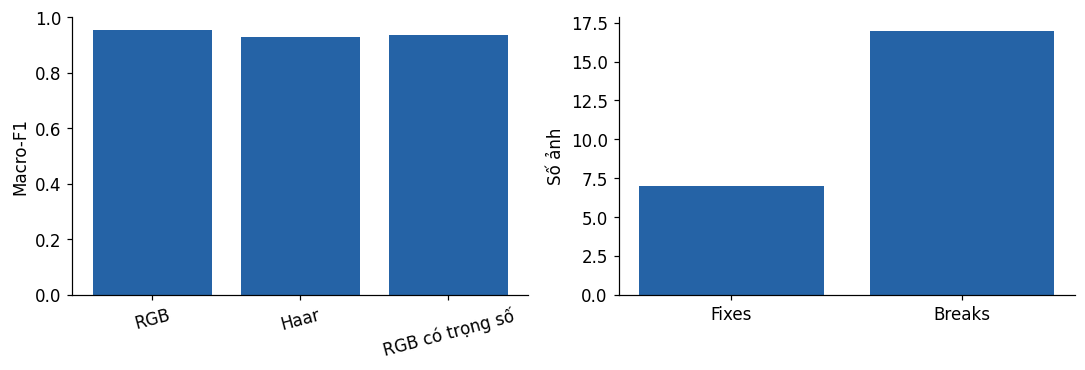

In [22]:
wavelet_report = paired_report(results, "rgb_prob", "wavelet_prob")
display(pd.DataFrame([wavelet_report]))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(metrics["Nhánh"], metrics["Macro-F1"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Macro-F1")
axes[0].tick_params(axis="x", rotation=15)
axes[1].bar(["Fixes", "Breaks"], [wavelet_report["fixes"], wavelet_report["breaks"]])
axes[1].set_ylabel("Số ảnh")
fig.tight_layout()
fig.savefig(ws.output_root / f"{MODE}_wavelet_comparison.png", dpi=150)
plt.show()

## 8. Trọng số mẫu: nhóm mục tiêu có tốt hơn không?

Điểm tổng có thể tăng trong khi nhóm Fake ít biên vẫn sai thêm. Ta dùng ngưỡng đã chọn từ train của từng fold để xem riêng nhóm này và nhóm Real ít biên.

Nếu nhóm mục tiêu quá nhỏ hoặc không có ảnh, bảng ghi số ảnh để ta biết giới hạn của phép so sánh. Cải thiện vài ảnh trên một fold chưa đủ để kết luận hướng này ổn định.

,A,B,n,A Macro-F1,B Macro-F1,A errors,B errors,fixes,breaks,net errors (B - A)
0,edge_base_prob,edge_weighted_prob,400,0.952493,0.934974,19,26,3,10,7


,fold,Nhóm,n,RGB errors,Weighted errors,cutoff từ train
0,0,Fake ít biên,46,1,0,0.014156
1,0,Real ít biên,10,1,1,0.014156


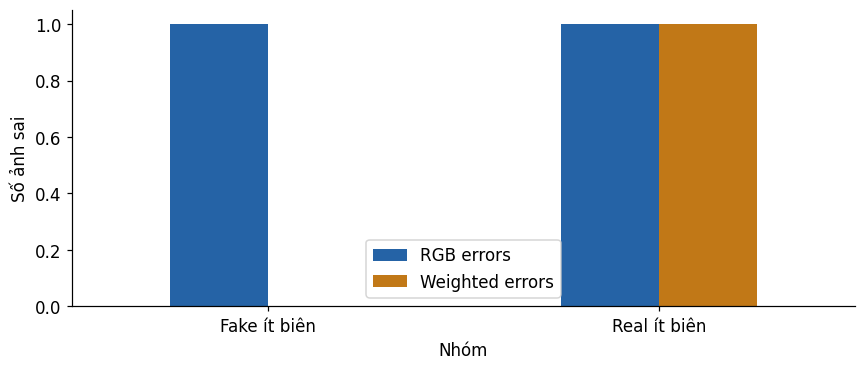

In [23]:
edge_report = paired_report(results, "edge_base_prob", "edge_weighted_prob")
display(pd.DataFrame([edge_report]))
subgroup_rows = []
for fold, frame in results.groupby("fold"):
    for label, name in [(1, "Fake ít biên"), (0, "Real ít biên")]:
        group = frame[(frame.label == label) & (frame.edge_ratio < cutoffs[int(fold)])]
        baseline_errors = int(((group.edge_base_prob >= 0.5).astype(int) != group.label).sum())
        weighted_errors = int(((group.edge_weighted_prob >= 0.5).astype(int) != group.label).sum())
        subgroup_rows.append({"fold": int(fold), "Nhóm": name, "n": len(group),
                              "RGB errors": baseline_errors, "Weighted errors": weighted_errors,
                              "cutoff từ train": cutoffs[int(fold)]})
subgroups = pd.DataFrame(subgroup_rows)
display(subgroups)
fig, ax = plt.subplots(figsize=(8, 3.5))
subgroups.groupby("Nhóm")[["RGB errors", "Weighted errors"]].sum().plot.bar(ax=ax, rot=0)
ax.set_ylabel("Số ảnh sai")
fig.tight_layout()
fig.savefig(ws.output_root / f"{MODE}_edge_subgroups.png", dpi=150)
plt.show()

### Tách dữ liệu chọn ngưỡng và dữ liệu đánh giá

Ngưỡng được chọn trên calibration, sau đó giữ nguyên khi chấm evaluation. Phần này dùng xác suất RGB của bài tập; phép thử Legal7 trong Reading được đối chiếu riêng ở cuối bài.

In [24]:
# Định nghĩa trực tiếp trong cell: calibration_split,choose_group_thresholds
def calibration_split(frame: pd.DataFrame, seed: int = 2026) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split each held-out fold by label and gray flag, without crossing train rows."""
    if len(frame) < 4 or not frame.file_name.is_unique:
        raise ValueError("Calibration requires unique names and at least four held-out rows.")
    rng = np.random.default_rng(seed)
    calibration = []
    for _, group in frame.groupby(["label", "is_gray"], sort=True):
        indices = rng.permutation(group.index.to_numpy())
        calibration.extend(indices[:len(indices) // 2])
    mask = frame.index.isin(calibration)
    if not mask.any() or mask.all():
        raise ValueError("Calibration and evaluation must both be nonempty.")
    return frame.loc[mask].copy(), frame.loc[~mask].copy()


def choose_group_thresholds(calibration: pd.DataFrame, probability: str = "rgb_prob") -> dict[int, float]:
    """Grid search on calibration only; missing/single-class groups keep 0.5."""
    chosen = {}
    grid = np.round(np.arange(0.30, 0.701, 0.01), 2)
    for flag in (0, 1):
        group = calibration[calibration.is_gray == flag]
        if group.label.nunique() < 2:
            chosen[flag] = 0.5
            continue
        scores = [(float(classification_report(group.label, group[probability], threshold=float(t))["macro_f1"]),
                   -abs(float(t) - 0.5), -float(t), float(t)) for t in grid]
        chosen[flag] = max(scores)[-1]
    return chosen

## 9. Chọn ngưỡng trên calibration, chấm trên evaluation

Trong mỗi fold validation, ta tách khoảng một nửa làm calibration, phần còn lại làm evaluation; cách chia giữ các nhóm nhãn và xám/màu. Mô hình không học cả hai phần này.

Ta thử ngưỡng 0,30 đến 0,70 trên calibration. Nhóm thiếu một trong hai lớp giữ ngưỡng 0,5. Sau khi chọn xong, ta so ngưỡng mới với 0,5 **trên cùng phần evaluation**. Không dò lại ngưỡng bằng nhãn evaluation.

Bước này chọn ngưỡng từ xác suất RGB. Ví dụ Legal7 ở cuối bài dùng xác suất của mô hình ghép; đọc hai kết quả cùng nguồn xác suất và cách chia dữ liệu tương ứng.

,fold,calibration_n,evaluation_n,gray_threshold,color_threshold
0,0,198,202,0.39,0.54


,Ngưỡng,n,Macro-F1
0,0.5,202,0.940571
1,Chọn trên calibration,202,0.940571


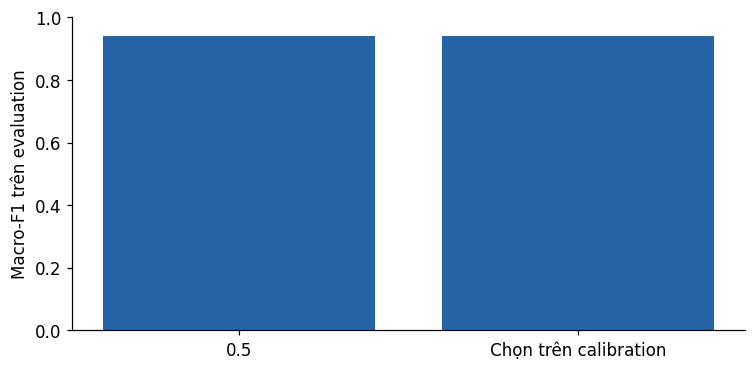

In [25]:
threshold_rows, evaluation_frames = [], []
for fold, frame in results.groupby("fold"):
    calibration, evaluation = calibration_split(frame, seed=cfg.seed + int(fold))
    chosen = choose_group_thresholds(calibration, probability="rgb_prob")
    evaluation["chosen_threshold"] = evaluation.is_gray.map(chosen)
    evaluation["prediction_default"] = (evaluation.rgb_prob >= 0.5).astype(int)
    evaluation["prediction_calibrated"] = (evaluation.rgb_prob >= evaluation.chosen_threshold).astype(int)
    evaluation_frames.append(evaluation)
    threshold_rows.append({"fold": int(fold), "calibration_n": len(calibration),
                           "evaluation_n": len(evaluation), "gray_threshold": chosen[1],
                           "color_threshold": chosen[0]})
thresholds = pd.DataFrame(threshold_rows)
evaluation = pd.concat(evaluation_frames, ignore_index=True)
display(thresholds)
threshold_report = pd.DataFrame([
    {"Ngưỡng": "0.5", "n": len(evaluation),
     "Macro-F1": macro_f1(evaluation.label, evaluation.prediction_default)},
    {"Ngưỡng": "Chọn trên calibration", "n": len(evaluation),
     "Macro-F1": macro_f1(evaluation.label, evaluation.prediction_calibrated)},
])
display(threshold_report)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(threshold_report["Ngưỡng"], threshold_report["Macro-F1"])
ax.set_ylim(0, 1)
ax.set_ylabel("Macro-F1 trên evaluation")
fig.tight_layout()
fig.savefig(ws.output_root / f"{MODE}_threshold_evaluation.png", dpi=150)
plt.show()

### Đọc lại các kết quả lịch sử trong Phụ lục D

Ở chế độ `reference`, các bảng dưới dùng feature, cutoff và ngưỡng đã lưu trong bundle, có kèm thông tin nguồn. Phần Legal7 so sánh ngưỡng cố định, ngưỡng theo fold và trung vị của các ngưỡng.

Bảng đóng góp vào stack đọc từ `promotion_gates.json`: so lỗi của stack trước và sau khi thay nhánh, rồi xem thay đổi có nằm trong nhóm Fake ít biên hay không.

In [26]:
if MODE == "reference":
    from sklearn.metrics import f1_score
    bundle = TASK / "data/negative_results"
    gate_receipt = json.loads((bundle / "promotion_gates.json").read_text())
    display(subgroups.groupby("Nhóm")[["n", "RGB errors", "Weighted errors"]].sum())
    print("Kết quả ghép mô hình đã lưu:")
    display({key: value for key, value in gate_receipt.items() if key not in {"cutoffs", "fold_subgroup"}})
    saved = pd.read_csv(bundle / "threshold_choices.csv").set_index("fold")
    history = results.copy()
    history["crossfit_t"] = [saved.loc[int(fold), "gray_threshold" if gray else "color_threshold"]
                              for fold, gray in zip(history.fold, history.is_gray)]
    history["median_t"] = np.where(history.is_gray, saved.gray_threshold.median(), saved.color_threshold.median())
    historical_scores = []
    for name, threshold in [("Cố định 0.50", .5), ("Trung vị 5 ngưỡng, chấm lại OOF", history.median_t),
                            ("Ngưỡng của fold giữ lại", history.crossfit_t)]:
        pred = history.legacy_stack_prob >= threshold
        historical_scores.append({"Cách đo Legal7": name, "n": len(history),
                                  "Macro-F1": f1_score(history.label, pred, average="macro"),
                                  "errors": int((pred != history.label).sum())})
    display(pd.DataFrame(historical_scores))
    history.to_csv(ws.output_root / "historical_legal7_threshold_replay.csv", index=False)

## 10. Lưu kết quả và quyết định bước tiếp theo

Cell cuối lưu dự đoán, bảng điểm, ngưỡng và danh sách checkpoint của lượt chạy. Các hình phía trên cũng được lưu dưới dạng PNG. Đây là báo cáo ablation trên ảnh có nhãn, không phải điểm Private Test.

Khi đọc kết quả, hãy nêu rõ số fold, số ảnh và số epoch. Với Wavelet, xem fixes/breaks; với trọng số, xem nhóm mục tiêu; với ngưỡng, xem phần evaluation. Nếu muốn thử tiếp, đổi một yếu tố rồi chạy lại cùng cách chia dữ liệu.

In [27]:
output = ws.output_root / MODE
output.mkdir(parents=True, exist_ok=True)
for name, table in [("validation_predictions", results), ("metrics", metrics),
                    ("edge_subgroups", subgroups), ("threshold_choices", thresholds),
                    ("threshold_evaluation", evaluation), ("threshold_metrics", threshold_report)]:
    table.to_csv(output / f"{name}.csv", index=False)
receipt = {"mode": MODE, "folds": sorted(int(f) for f in results.fold.unique()), "epochs": EPOCHS if MODE == "train" else None,
           "config": cfg.to_dict() if MODE == "train" else None,
           "validation_rows": len(results), "threshold_evaluation_rows": len(evaluation),
           "wavelet": wavelet_report, "edge_weighting": edge_report,
           "cutoffs_from_training": cutoffs,
           "checkpoints": [str(run.checkpoint_path) for run in runs.values()]}
(output / "run_summary.json").write_text(json.dumps(receipt, ensure_ascii=False, indent=2), encoding="utf-8")
print("Đã lưu báo cáo:", output)
print("Đã lưu hình:", ws.output_root)
print("Chạy xong bài 4.")

Đã lưu báo cáo: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/lesson_nb4_reading_v2/train
Đã lưu hình: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/lesson_nb4_reading_v2
Chạy xong bài 4.
